# Equilibrium Model: BRNS 2.0 vs. BRNS 3.0

This notebook compares equilibrium output profiles between:

- BRNS 2.0 reference data from `paper/equilibrium`
- BRNS 3.0 result data from `build/equilibrium/results/python`

It reproduces two paper-style panels:

1. POM profile from `ch2o.inp`
2. Denitrification profile from `deni.dat`

## Plotted Quantities

- Left panel: x = POM ($\mu$mol/g), y = depth in sediment (cm)
- Right panel: x = denitrification ($\mu$mol/(cm$^3$a)), y = depth in sediment (cm)

Depth is plotted downward (inverted y-axis), consistent with sediment-profile convention.

In [1]:
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

REF_DIR = Path(os.environ.get('BRNS_EQ_REF_DIR', 'paper/equilibrium'))
RES_DIR = Path(os.environ.get('BRNS_EQ_RESULT_DIR', 'build/equilibrium/results/python'))
FIGURE_PATH = Path(os.environ.get('BRNS_EQ_FIGURE', 'paper/equilibrium_brns2_brns3_comparison.pdf'))

POM_FACTOR_TO_UMOL_G = 2.5*0.85*1000*1000
DENI_FACTOR_TO_UMOL_CM3_A = 1000

om_x = 200.0
om_y = 21.0
s_dens = 2.5
por0 = 0.85
SD = s_dens*(1-por0)/por0*1000

FAKTOR = (4*om_x + 3*om_y)/(5*om_x) * SD

print('Reference directory :', REF_DIR)
print('Result directory    :', RES_DIR)
print('Figure output       :', FIGURE_PATH)
print('POM factor          :', POM_FACTOR_TO_UMOL_G)
print('Deni factor         :', DENI_FACTOR_TO_UMOL_CM3_A)

if not REF_DIR.exists():
    raise FileNotFoundError(f'Reference directory not found: {REF_DIR}')
if not RES_DIR.exists():
    raise FileNotFoundError(f'Result directory not found: {RES_DIR}')

Reference directory : paper/equilibrium
Result directory    : build/equilibrium/results/python
Figure output       : paper/equilibrium_brns2_brns3_comparison.pdf
POM factor          : 2125000.0
Deni factor         : 1000


In [2]:
def load_two_column_profile(path: Path) -> np.ndarray:
    if not path.exists():
        raise FileNotFoundError(f'Missing file: {path}')
    arr = np.loadtxt(path)
    if arr.ndim != 2 or arr.shape[1] < 2:
        raise ValueError(f'Unexpected format in {path}: expected at least two columns')
    return np.asarray(arr[:, :2], dtype=float)


def split_snapshots_by_depth(arr2: np.ndarray) -> list[np.ndarray]:
    depth = arr2[:, 1]
    split_idx = np.where(np.diff(depth) < 0.0)[0] + 1
    if split_idx.size == 0:
        return [arr2]
    blocks = np.split(arr2, split_idx)
    return [blk for blk in blocks if blk.size > 0]


def last_snapshot(arr2: np.ndarray) -> np.ndarray:
    snaps = split_snapshots_by_depth(arr2)
    return snaps[-1]


def prepare_sorted(arr2: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    values = np.asarray(arr2[:, 0], dtype=float)
    depth = np.asarray(arr2[:, 1], dtype=float)
    order = np.argsort(depth)
    return values[order], depth[order]


# Left panel data: ch2o.inp
pom_ref_raw = load_two_column_profile(REF_DIR / 'ch2o.inp')
pom_res_raw = load_two_column_profile(RES_DIR / 'ch2o.inp')

pom_ref, depth_ref_pom = prepare_sorted(pom_ref_raw)
pom_res, depth_res_pom = prepare_sorted(pom_res_raw)

# Right panel data: deni.dat (may contain multiple snapshots)
deni_ref_raw = load_two_column_profile(REF_DIR / 'deni.dat')
deni_res_raw = load_two_column_profile(RES_DIR / 'deni.dat')

deni_ref_last = last_snapshot(deni_ref_raw)
deni_res_last = last_snapshot(deni_res_raw)

deni_ref, depth_ref_deni = prepare_sorted(deni_ref_last)
deni_res, depth_res_deni = prepare_sorted(deni_res_last)

pom_ref_u = pom_ref * POM_FACTOR_TO_UMOL_G
pom_res_u = pom_res * POM_FACTOR_TO_UMOL_G
deni_ref_u = deni_ref * DENI_FACTOR_TO_UMOL_CM3_A * FAKTOR
deni_res_u = deni_res * DENI_FACTOR_TO_UMOL_CM3_A * FAKTOR

print('POM rows, BRNS 2.0:', pom_ref_u.shape[0])
print('POM rows, BRNS 3.0:', pom_res_u.shape[0])
print('Deni rows (last snapshot), BRNS 2.0:', deni_ref_u.shape[0])
print('Deni rows (last snapshot), BRNS 3.0:', deni_res_u.shape[0])

POM rows, BRNS 2.0: 111
POM rows, BRNS 3.0: 111
Deni rows (last snapshot), BRNS 2.0: 111
Deni rows (last snapshot), BRNS 3.0: 111


In [3]:
def _align_on_reference_depth(depth_ref: np.ndarray, value_ref: np.ndarray, depth_res: np.ndarray, value_res: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Interpolate result values to reference depth for a pointwise error comparison."""
    depth_ref = np.asarray(depth_ref, dtype=float)
    value_ref = np.asarray(value_ref, dtype=float)
    depth_res = np.asarray(depth_res, dtype=float)
    value_res = np.asarray(value_res, dtype=float)

    order_ref = np.argsort(depth_ref)
    order_res = np.argsort(depth_res)
    depth_ref_s = depth_ref[order_ref]
    value_ref_s = value_ref[order_ref]
    depth_res_s = depth_res[order_res]
    value_res_s = value_res[order_res]

    res_interp = np.interp(depth_ref_s, depth_res_s, value_res_s)
    return depth_ref_s, value_ref_s, res_interp


def _error_stats(reference: np.ndarray, estimate: np.ndarray, rel_floor: float = 1.0e-20) -> dict[str, float | np.ndarray]:
    diff = np.asarray(estimate, dtype=float) - np.asarray(reference, dtype=float)
    abs_err = np.abs(diff)
    rel_err = abs_err / np.maximum(np.abs(reference), rel_floor)
    return {
        'abs_err': abs_err,
        'rel_err': rel_err,
        'mae': float(np.mean(abs_err)),
        'max_abs': float(np.max(abs_err)),
        'rmse': float(np.sqrt(np.mean(diff ** 2))),
        'mre': float(np.mean(rel_err)),
        'max_rel': float(np.max(rel_err)),
    }


# Compare POM on common (reference) depth grid
depth_pom_cmp, pom_ref_cmp, pom_res_cmp = _align_on_reference_depth(
    depth_ref_pom, pom_ref_u, depth_res_pom, pom_res_u
)
err_pom = _error_stats(pom_ref_cmp, pom_res_cmp)

# Compare denitrification on common (reference) depth grid
depth_deni_cmp, deni_ref_cmp, deni_res_cmp = _align_on_reference_depth(
    depth_ref_deni, deni_ref_u, depth_res_deni, deni_res_u
)
err_deni = _error_stats(deni_ref_cmp, deni_res_cmp)

print('Error summary (BRNS 3.0 vs BRNS 2.0 reference)')
print('=' * 108)
print(f"{'Quantity':<20} {'MAE':>14} {'Max |abs|':>14} {'RMSE':>14} {'Mean rel [%]':>16} {'Max rel [%]':>16}")
print('-' * 108)
print(f"{'POM':<20} {err_pom['mae']:14.6e} {err_pom['max_abs']:14.6e} {err_pom['rmse']:14.6e} {100.0 * err_pom['mre']:16.6e} {100.0 * err_pom['max_rel']:16.6e}")
print(f"{'Denitrification':<20} {err_deni['mae']:14.6e} {err_deni['max_abs']:14.6e} {err_deni['rmse']:14.6e} {100.0 * err_deni['mre']:16.6e} {100.0 * err_deni['max_rel']:16.6e}")

print('')
print('Pointwise arrays are available as:')
print('  err_pom[\'abs_err\'], err_pom[\'rel_err\']')
print('  err_deni[\'abs_err\'], err_deni[\'rel_err\']')

Error summary (BRNS 3.0 vs BRNS 2.0 reference)
Quantity                        MAE      Max |abs|           RMSE     Mean rel [%]      Max rel [%]
------------------------------------------------------------------------------------------------------------
POM                    0.000000e+00   0.000000e+00   0.000000e+00     0.000000e+00     0.000000e+00
Denitrification        0.000000e+00   0.000000e+00   0.000000e+00     0.000000e+00     0.000000e+00

Pointwise arrays are available as:
  err_pom['abs_err'], err_pom['rel_err']
  err_deni['abs_err'], err_deni['rel_err']


Saved figure to paper/equilibrium_brns2_brns3_comparison.pdf


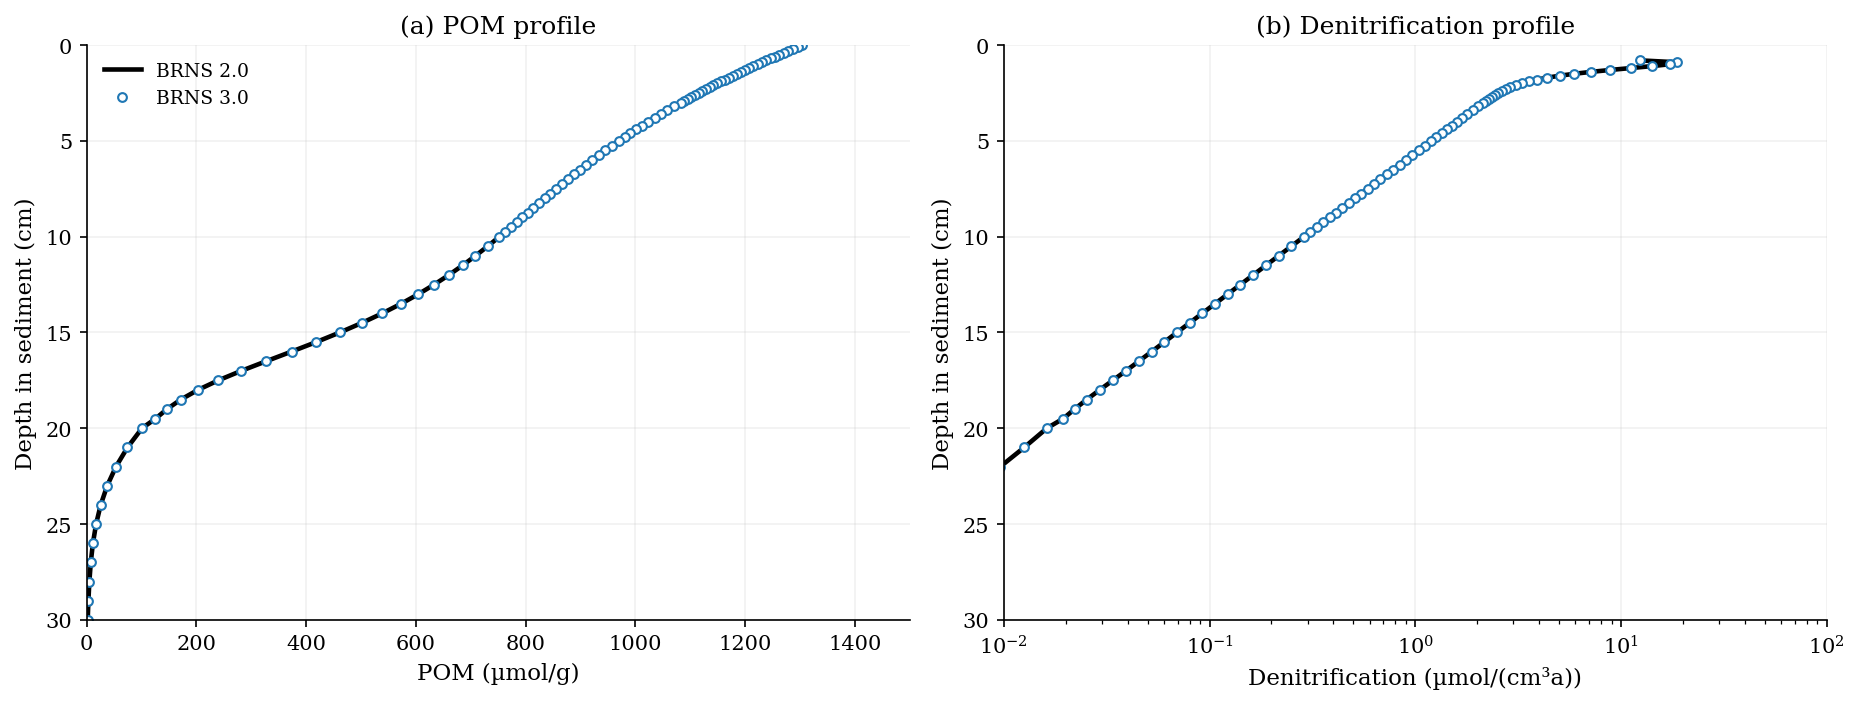

In [4]:
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'STIX Two Text', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
})

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharey=False)

# Left panel: POM
ax = axes[0]
ax.plot(pom_ref_u, depth_ref_pom, color='black', linewidth=2.2, label='BRNS 2.0')
ax.plot(pom_res_u, depth_res_pom, linestyle='none', marker='o', markersize=4.2, markerfacecolor='white', markeredgewidth=1.0, color='#1f77b4', label='BRNS 3.0')
ax.set_xlabel('POM (µmol/g)')
ax.set_ylabel('Depth in sediment (cm)')
ax.set_title('(a) POM profile')
ax.set_ylim([0.0, 30.0])
ax.set_xlim([0, 1500])
ax.grid(True, which='major', alpha=0.18)
ax.invert_yaxis()
ax.legend(loc='best', frameon=False)

# Right panel: Denitrification
ax = axes[1]
ax.plot(deni_ref_u[8:], depth_ref_deni[8:], color='black', linewidth=2.2, label='BRNS 2.0')
ax.plot(deni_res_u[8:], depth_res_deni[8:], linestyle='none', marker='o', markersize=4.2, markerfacecolor='white', markeredgewidth=1.0, color='#1f77b4', label='BRNS 3.0')
ax.set_xlabel('Denitrification (µmol/(cm³a))')
ax.set_ylabel('Depth in sediment (cm)')
ax.set_title('(b) Denitrification profile')
ax.set_ylim([0.0, 30.0])
ax.set_xlim([0.01, 100.0])
ax.grid(True, which='major', alpha=0.18)
ax.set_xscale('log')
ax.invert_yaxis()
#ax.legend(loc='best', frameon=False)

#fig.suptitle('Equilibrium example: comparison of BRNS 2.0 reference and BRNS 3.0 output', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()

FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURE_PATH, bbox_inches='tight')
print('Saved figure to', FIGURE_PATH)
plt.show()